# 🚨 Phishing URL Detection using NLP & Machine Learning  
### 🔐 Identify Malicious Websites with Data Science  

🔥 **Do Upvote if you find this notebook helpful!** 🔥  

Phishing attacks are one of the most common cyber threats today.  
In this notebook, we build an **end-to-end phishing URL classifier** using:

- 📊 Exploratory Data Analysis (EDA)
- 🧠 NLP-based feature engineering
- 🤖 Machine Learning models
- 📈 Clean & interpretable visualizations

This notebook is **beginner-friendly** and **industry-relevant**.


## 📂 Dataset Overview

Each row represents a website URL labeled as either **phishing** or **legitimate**.

### 📌 Columns
- **url** → Website link  
- **label** → `1 = Phishing`, `0 = Legitimate`  
- **source** → Data origin (OpenPhish, URLhaus, Tranco)

🎯 **Goal**: Predict whether a URL is phishing or not.


## Imports

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from urllib.parse import urlparse
import re

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.svm import SVC 
from xgboost import XGBClassifier 
from lightgbm import LGBMClassifier 
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score


## 📥 Load Dataset

In [3]:
df = pd.read_csv("data/raw.csv")
df.head()

,url,label,source
0,http://110.37.26.193:54956/bin.sh,1,urlhaus
1,https://sentry5.obor1shwron8.ru/4ylkytvt,1,urlhaus
2,https://d6gu.ripple-cask.ru/jid43vpd,1,urlhaus
3,http://130.12.180.34/596a96cc7bf9108cd896f33c4...,1,urlhaus
4,https://bronze.systems,0,tranco


## 📊 Basic Dataset Information

In [4]:
df.info()
df["label"].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 48812 entries, 0 to 48811
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   url     48812 non-null  str  
 1   label   48812 non-null  int64
 2   source  48812 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.1 MB


label
1    24406
0    24406
Name: count, dtype: int64

## ⚖️ Class Balance

C:\Users\sad57\AppData\Local\Temp\ipykernel_35872\303655582.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="label", data=df, palette="Set2")


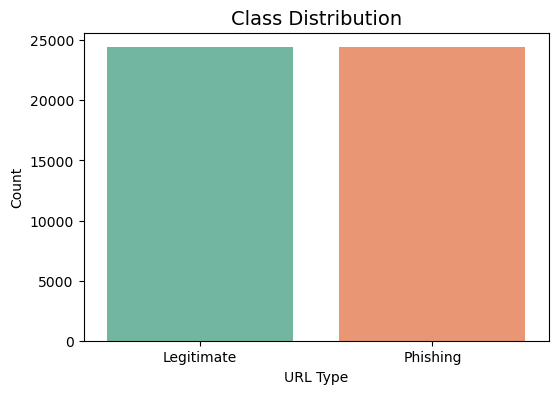

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x="label", data=df, palette="Set2")
plt.xticks([0,1], ["Legitimate", "Phishing"])
plt.title("Class Distribution", fontsize=14)
plt.xlabel("URL Type")
plt.ylabel("Count")
plt.show()

## 📝 TF-IDF Vectorization of URLs

We convert URLs into numerical text features using **TF-IDF**.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df['url'])

y = df['label']

## 🔀 Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 🤖 Test Multi Models 

In [8]:
models= {
    'lr': LogisticRegression(max_iter=1000),  
    "KNN": KNeighborsClassifier(n_neighbors=3, n_jobs=-1), 
    "rf": RandomForestClassifier(n_estimators=200, n_jobs=-1), 
    "XGB": XGBClassifier(n_estimators= 200, n_jobs= -1), 
    "LGMB": LGBMClassifier(n_estimators=200, n_jobs=-1)
}

In [12]:
results= []
for name, model in models.items():  
    model.fit(X_train, y_train) 
    y_pred= model.predict(X_test) 
    acc= accuracy_score(y_test, y_pred) 
    report= classification_report(y_test, y_pred) 
    y_prob = model.predict_proba(X_test)[:,1] 
    roc_auc= roc_auc_score(y_test, y_prob)
    print(f"Model: {name}")
    print('Accuracy:', acc)
    print("Classification Report:\n",report)
    print("ROC AUC:", roc_auc) 
    print('-' * 150)
    results.append(
        {
            "Model": name, 
            'Accuracy': acc, 
            "ROC AUC": roc_auc
        }
    )
    

Model: lr
Accuracy: 0.9772610877803953
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.96      0.98      4786
           1       0.97      0.99      0.98      4977

    accuracy                           0.98      9763
   macro avg       0.98      0.98      0.98      9763
weighted avg       0.98      0.98      0.98      9763

ROC AUC: 0.9991098207626373
------------------------------------------------------------------------------------------------------------------------------------------------------
Model: KNN
Accuracy: 0.9823824644064324
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98      4786
           1       0.99      0.97      0.98      4977

    accuracy                           0.98      9763
   macro avg       0.98      0.98      0.98      9763
weighted avg       0.98      0.98      0.98      9763

ROC AUC: 0.9932549947056922
------------

c:\Users\sad57\anaconda3\envs\ml_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\sad57\anaconda3\envs\ml_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [13]:
df_results= pd.DataFrame(results).sort_values(ascending=False, by='Accuracy') 
df_results

,Model,Accuracy,ROC AUC
2,rf,0.997849,0.999532
4,LGMB,0.995391,0.999537
3,XGB,0.993957,0.999379
1,KNN,0.982382,0.993255
0,lr,0.977261,0.999110


# Cross Val Score on Random Forest

In [16]:
model = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42) 

In [19]:
scores= cross_val_score(estimator=model, X=X, y= y, n_jobs=-1, cv=10, scoring='accuracy')
print('All Scores:', scores)
print("AVG Scores:", scores.mean())

All Scores: [0.99897583 0.99754199 0.99754149 0.99713174 0.99774636 0.99795124
 0.99815612 0.99815612 0.99754149 0.99836099]
AVG Scores: 0.9979103356316215


In [20]:
scores= cross_val_score(estimator=model, X=X, y= y, n_jobs=-1, cv=10, scoring='f1')
print('All Scores:', scores)
print("AVG Scores:", scores.mean())

All Scores: [0.99897646 0.997543   0.99753796 0.99712879 0.99774636 0.99794998
 0.99815612 0.99815309 0.99753998 0.998362  ]
AVG Scores: 0.9979093727395281


# Test Model 

In [34]:
tfidf = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3,5)
)

X = tfidf.fit_transform(df['url'])

y = df['label']

model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [39]:
def predict_url(input_url: str):

    transformed_url = tfidf.transform([input_url])

    prediction = model.predict(transformed_url)[0]

    probability = model.predict_proba(transformed_url)

    confidence = max(probability[0]) * 100

    label = "Legitimate" if prediction == 0 else "Phishing"

    return {
        "Prediction": label,
        "Confidence": f"{confidence:.2f}%"
    }

In [40]:
predict_url("https://linkedin.com")

{'Prediction': 'Legitimate', 'Confidence': '100.00%'}

In [41]:
predict_url( "https://github.com")

{'Prediction': 'Legitimate', 'Confidence': '99.50%'}

In [42]:
predict_url("http://google-login-security.xyz")

{'Prediction': 'Phishing', 'Confidence': '74.00%'}

In [43]:
predict_url("http://free-money-login.xyz")

{'Prediction': 'Phishing', 'Confidence': '90.50%'}

In [44]:
predict_url("http://192.168.1.1/login")

{'Prediction': 'Phishing', 'Confidence': '98.50%'}

In [45]:
predict_url("http://crypto-investment-profit-fast.net")

{'Prediction': 'Phishing', 'Confidence': '91.50%'}